In [13]:
import json
import numpy as np
import os 

carpeta_sim = "rund_yo"
with open(os.path.join(carpeta_sim, 'config.json'), 'r') as f:
    config = json.load(f)

nx = config['WIDTH']
ny = config['HEIGHT']
dx = config['dx']
dy = config['dy']
x = np.arange(0, nx) * dx
y = np.arange(0, ny) * dy

In [4]:
t = np.loadtxt("rund_yo/times_sim.txt")

In [5]:
eta = np.load("rund_yo/stacked.npy")

In [6]:
import matplotlib.pyplot as plt 

In [7]:
eta.shape

(18466, 8192)

In [8]:
t.shape

(18466,)

In [10]:
np.diff(t).min()

np.float64(0.006057825328127819)

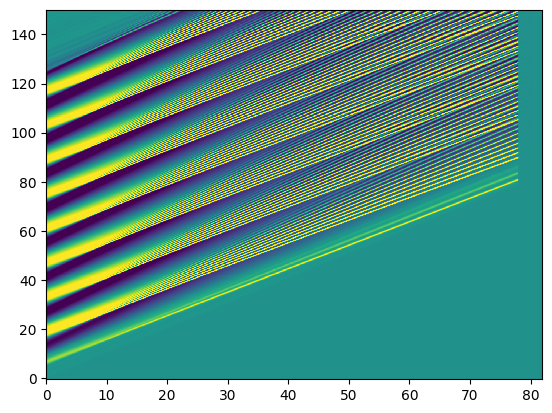

In [17]:
plt.pcolormesh(x, t[::20], eta[::20,:],vmin=-0.01,vmax=0.01)

In [21]:
!ls ../../trillo_comparisons/

-p
01-stage-I-ts-comparison.ipynb
02-stage-I-lags-comparison.ipynb
03-peaks-trajectories-save-kdv.ipynb
03-peaks-trajectories-save-lab.ipynb
03-peaks-trajectories-save-sgn.ipynb
03-peaks-trajectories-save-whitham.ipynb
04-peak-trajectories-elevations.ipynb
04-peaks-paths-comparison.ipynb
04-peaks-trajectories-celerities.ipynb
04-peaks-trajectories-save.ipynb
05-nft-compare.ipynb
05-nft-compute-kdv.ipynb
05-nft-compute-lab.ipynb
05-nft-compute-lab.py
05-nft-compute-runc.ipynb
05-nft-compute-sgn-ideal.ipynb
05-nft-compute-sgn-real.ipynb
05-nft-compute-whitham.ipynb
05-nft-mesh-sensitivity.ipynb
05-nft-old.ipynb
05-sgn-synth-experiments-design.ipynb
06-dengetal-comparison.ipynb
07-peaks-trajectories-nft.ipynb
08-mesh-convergence-kdv.ipynb
08-mesh-convergence-sgn.ipynb
08-mesh-convergence-whitham.ipynb
09-breaking-sensitivity.ipynb
10-depth-sensiivity-paths.ipynb
10-depth-sensitivity-runner.py
10-depth-sensitivity.ipynb
10-depth_sensitivity
111-analyze-wavemaker.ipynb
111-peaks-trajectorie

In [22]:
def get_sgn(run):
    sgn =  dict (
        h = np.loadtxt(f"../../trillo_comparisons/sgn/base/ro015_{run.lower()}/calc01/Hj.dat"),
        x = np.loadtxt(f"../../trillo_comparisons/sgn/base/ro015_{run.lower()}/calc01/Xj.dat")+5,
        t = np.loadtxt(f"../../trillo_comparisons/sgn/base/ro015_{run.lower()}/calc01/time.dat"),
    )


    sgn["gauges_indices"] = [
                np.argmin(np.abs(sgn["x"] - (xi - 0)))
                for xi in [5, 15, 25, 35, 45, 55, 65, 75]
    ]

    sgn["hgauges"] = sgn["h"][:, sgn["gauges_indices"]]
    return sgn

In [24]:
sgn = get_sgn("rund")

In [27]:
sgn["h"]-=0.1

In [29]:
sgn["h"].shape, sgn["x"].shape

((5944, 10169), (10169,))

Text(0.5, 1.0, 'ms')

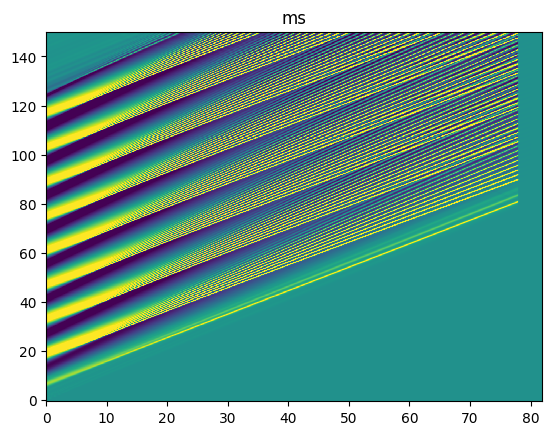

In [37]:
plt.pcolormesh(x, t[::20], eta[::20,:],vmin=-0.01,vmax=0.01)
plt.title("ms")

Text(0.5, 1.0, 'sgn')

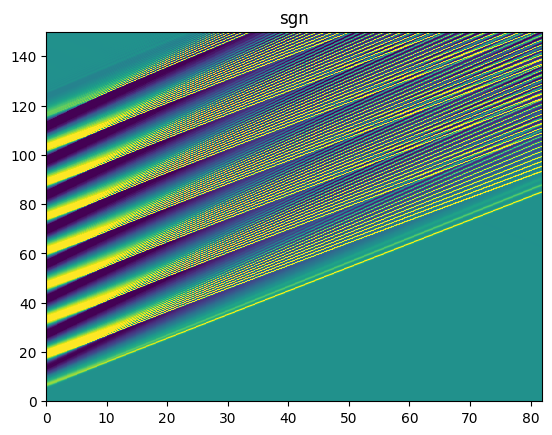

In [38]:
plt.pcolormesh(sgn["x"][::10]-5, sgn["t"],sgn["h"][:,::10],vmin=-0.01,vmax=0.01)
plt.xlim(0,x.max())
plt.ylim(0,t.max())
plt.title("sgn")

In [42]:
sgn_xloc

np.int64(667)

In [ ]:
x0 = 5

for index,x0 in enumerate([5,15,25,35,45,55,65,75]):
    ms_xloc = np.argmin(np.abs(x+5-x0))
    sgn_xloc = np.argmin(np.abs(sgn["x"]-x0))

    plt.figure()
    plt.plot(t, eta[:,ms_xloc],alpha=1.0,label="ms")
    plt.plot(sgn["t"], sgn["h"][:,int(sgn_xloc)],alpha=0.8,label="sgn")
    plt.legend()
    plt.xlim(index*10,50+index*10)
    plt.title(f"x={x0}")